In [134]:
import math
import numpy as np 
import matplotlib.pyplot as plt 
%matplotlib inline

In [135]:
a = 2.0
b = -4.0
c = 10.0
h=0.001
d1=a*b +c
c+=h
d2=a*b +c

m=(d2-d1)/h
print(d1)
print(d2)
print(m)


2.0
2.0009999999999994
0.9999999999994458


In [ ]:
class Value:
    def __init__(self, data, _children=(), _op='', label='None'):
        self.data=data
        self.label=label
        self._prev=set(_children)
        self._backward=lambda : None
        self._op=_op
        self.grad=0.0

    def __repr__(self):
        return f"Value(data={self.data}, label={self.label})"

    def __add__(self, other):
        out=Value(self.data + other.data,(self,other),"+")
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward= _backward
        return  out

    def __mul__(self, other):
        out=Value(self.data * other.data,(self,other),"*")
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward= _backward
        return  out

    def __pow__(self, other):
        out=Value(self.data ** other.data,(self,other),"**")
        return  out

    def __sub__(self, other):
        out=Value(self.data - other.data,(self,other),"-")
        return  out

    def __truediv__(self, other):
        out=Value(self.data / other.data,(self,other),"/")
        return  out

    def tanh(self):
        x=self.data
        t=(math.exp(2*x)-1)/(math.exp(2*x)+1)
        out=Value(t,(self,),"tanh")
        def _backward():
            self.grad += (1-t**2) * out.grad
        out._backward= _backward
        return out

    def  backward(self):
        topo=[]
        visited=set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        print(topo)
        
        self.grad=1.0
        for node in reversed(topo):
            node._backward()

    def zero_grad(self):
        # clears grads of every node in the graph. call it BEFORE the next
        # accumulation buffer starts, i.e. right before optimizer.step(),
        # never between the backward() calls of one batch.
        self.grad=0.0
        for child in self._prev:
            child.zero_grad()



    
    

In [137]:
x=Value(2.0)
x

Value(data=2.0, label=None)

In [138]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)
  return dot

In [139]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L

Value(data=-8.0, label=L)

In [140]:
# !winget install Graphviz.Graphviz


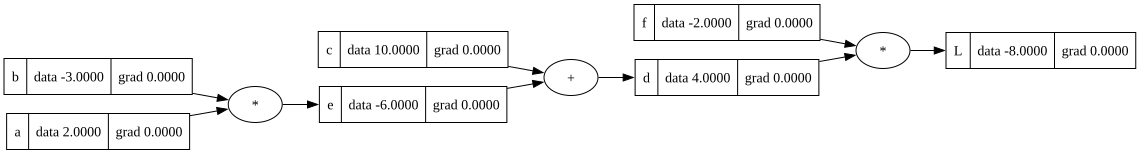

In [141]:
draw_dot(L)

In [142]:
sd=list(e._prev)
sd[0]

Value(data=-3.0, label=b)

In [143]:
L.grad=1.0

In [144]:
# dl/dl= 1 
# dd/dL = f.data * 1 #(1 is dL/dL)
f.grad= d.data *1
d.grad= f.data *1

In [145]:
# now e and c have +(linear) relationship with d
# de/dd= grad(d)
# dc/dd= grad(d)
e.grad=d.grad * 1
c.grad=d.grad * 1

>chain rule for global derivative affect, a local "+" cannot capture the whole operations ,,it just adds and gives a result

In [146]:

# now a and b have * relations wiith e
# e=a*b
# de/da = b
# de/db = a
# f(x+h)-f(x) / h = (a*b + h*b - a*b) / h = b
a.grad=e.grad * b.data
b.grad=e.grad * a.data

In [147]:
def check_for():
    h=0.001
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1=L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L2=L.data

    print((L2-L1)/h)
check_for()

0.0


In [148]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'

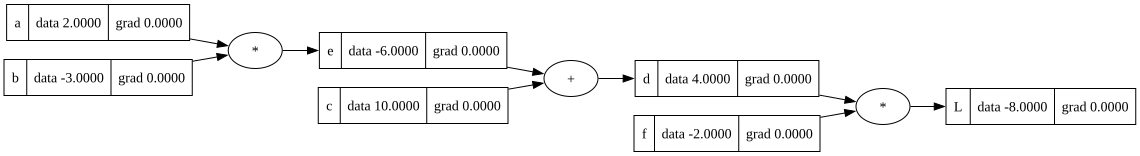

In [149]:
draw_dot(L)

In [150]:
L.grad=1.0

In [151]:
L._backward()

In [152]:
d._backward()

In [153]:
e._backward()

In [154]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

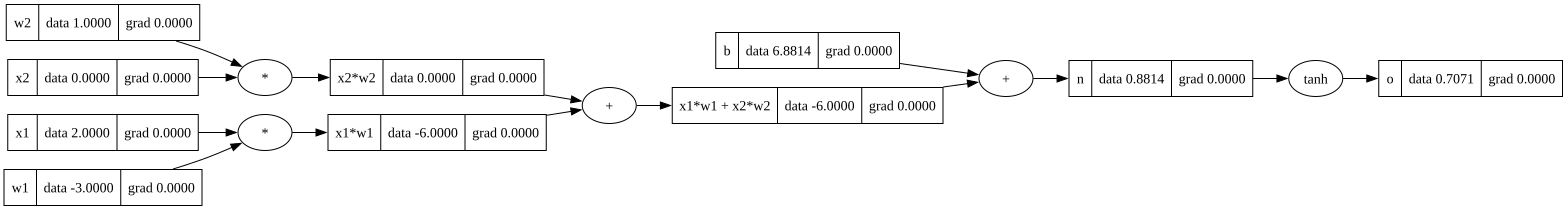

In [155]:
draw_dot(o)

> #### for when to backpropagate , we need to first compplete the forward pass and then we can backpropagate the gradients from the output node to the input nodes.
> Toplological Sorting helps here which only moves one ways L-> R, we can do that for forward pass then reverse the stored nodes to calculate the gradients.

In [156]:
topo = []
visited = set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)
build_topo(o)
topo

[Value(data=2.0, label=x1),
 Value(data=-3.0, label=w1),
 Value(data=-6.0, label=x1*w1),
 Value(data=1.0, label=w2),
 Value(data=0.0, label=x2),
 Value(data=0.0, label=x2*w2),
 Value(data=-6.0, label=x1*w1 + x2*w2),
 Value(data=6.881373587019543, label=b),
 Value(data=0.8813735870195432, label=n),
 Value(data=0.7071067811865476, label=o)]

In [168]:
o.backward()

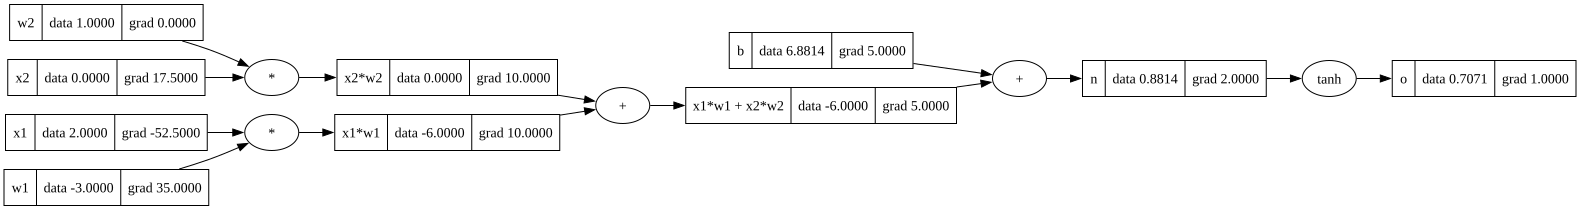

In [169]:
draw_dot(o)

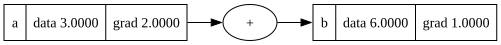

In [163]:
a = Value(3.0, label='a')
b = a + a   ; b.label = 'b'
b.backward()
draw_dot(b)